# 2 — Synthetic multi-scale raster

Constructs a 128×128 raster as a sum of sinusoids at three different spatial frequencies. Because each frequency lives cleanly at a specific aggregation scale, `scale_variance_raster` should show most of the variance at a handful of levels.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scalevar import scale_variance_raster

rng = np.random.default_rng(20260424)

## Build the input

Three cosine components at wavelengths 64, 16, and 4 pixels — corresponding roughly to level-4, level-3, and level-1 aggregations with `base_level_factor=2` — plus a small noise floor.

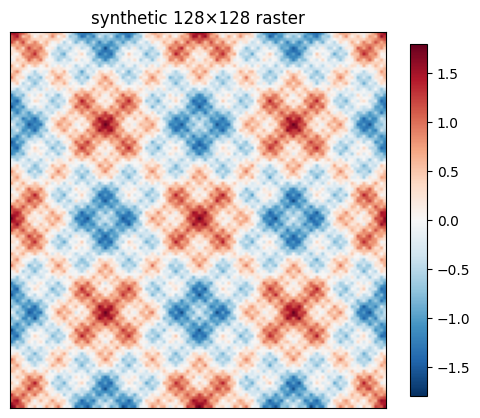

In [2]:
n = 128
y, x = np.mgrid[0:n, 0:n].astype(float)

coarse  = 1.0 * np.cos(2*np.pi*x/64) * np.cos(2*np.pi*y/64)
medium  = 0.6 * np.cos(2*np.pi*x/16) * np.cos(2*np.pi*y/16)
fine    = 0.3 * np.cos(2*np.pi*x/4)  * np.cos(2*np.pi*y/4)
noise   = 0.05 * rng.standard_normal((n, n))

raster = coarse + medium + fine + noise

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(raster, cmap='RdBu_r', vmin=-1.8, vmax=1.8, origin='lower')
ax.set_title('synthetic 128×128 raster')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
plt.show()

## Decompose across 8 levels

`num_levels=None` (default) auto-picks `floor(log_b(min(nrow, ncol))) + 1 = 8` levels for a 128×128 base-2 hierarchy.

In [3]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # numpy array carries no CRS — expected
    result = scale_variance_raster(raster, agg_fun='mean')

print(f'TSS        = {result.total_ss:.2f}')
print(f'grand_mean = {result.grand_mean:.4f}')
print(f'n_levels   = {result.n_levels}')
result.components.round(4)

TSS        = 5987.35
grand_mean = 0.0002
n_levels   = 8


,level,scale,sum_squares,df,mean_square,ss_share,ms_share,ss_cumulative
0,1,1.0,438.2835,12288,0.0357,0.0732,0.0006,0.0732
1,2,2.0,544.7743,3072,0.1773,0.0910,0.0028,0.1642
2,3,4.0,1292.0604,768,1.6824,0.2158,0.0265,0.3800
3,4,8.0,1008.6112,192,5.2532,0.1685,0.0828,0.5484
4,5,16.0,2703.5717,48,56.3244,0.4515,0.8873,1.0000
5,6,32.0,0.0307,12,0.0026,0.0000,0.0000,1.0000
6,7,64.0,0.0150,3,0.0050,0.0000,0.0001,1.0000
7,8,128.0,0.0000,0,NaN,0.0000,NaN,1.0000


## Plot the scale-variance lollipop

On a log x-axis the three structural peaks (4-pixel, 16-pixel, 64-pixel wavelengths) should be visible.

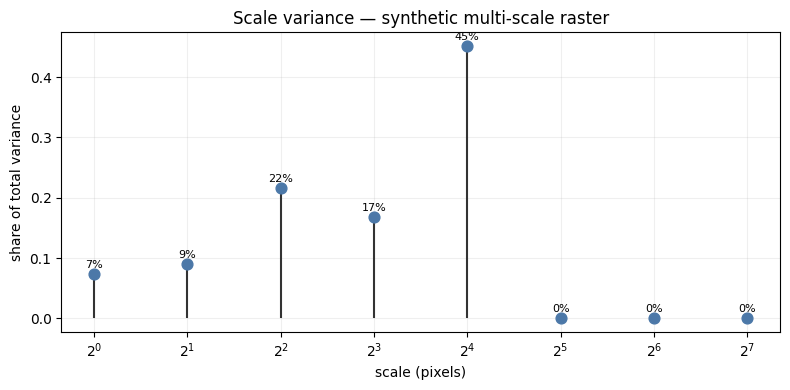

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
comp = result.components
ax.vlines(comp['scale'], 0, comp['ss_share'], color='#333', linewidth=1.5)
ax.scatter(comp['scale'], comp['ss_share'], s=60, color='#4c78a8', zorder=3)
ax.set_xscale('log', base=2)
ax.set_xlabel('scale (pixels)')
ax.set_ylabel('share of total variance')
ax.set_title('Scale variance — synthetic multi-scale raster')
ax.grid(True, which='both', alpha=0.2)
for _, row in comp.iterrows():
    ax.text(row['scale'], row['ss_share'] + 0.01, f"{row['ss_share']*100:.0f}%",
            ha='center', fontsize=8)
fig.tight_layout()
plt.show()

## Sanity checks

The same identities as the tabular case.

In [5]:
assert abs(result.components['sum_squares'].sum() - result.total_ss) < 1e-7
assert result.components['df'].sum() == result.total_df
assert abs(result.components['ss_share'].sum() - 1.0) < 1e-10
'identities hold'

'identities hold'

## Optional: inspect the per-cell SVE rasters

Passing `return_sve=True` returns `sve` as a `(num_levels, nrow, ncol)` numpy array — each band is the squared difference at one scale, mapped back to the finest grid. Useful for visualizing **where** variance accumulates at each scale.

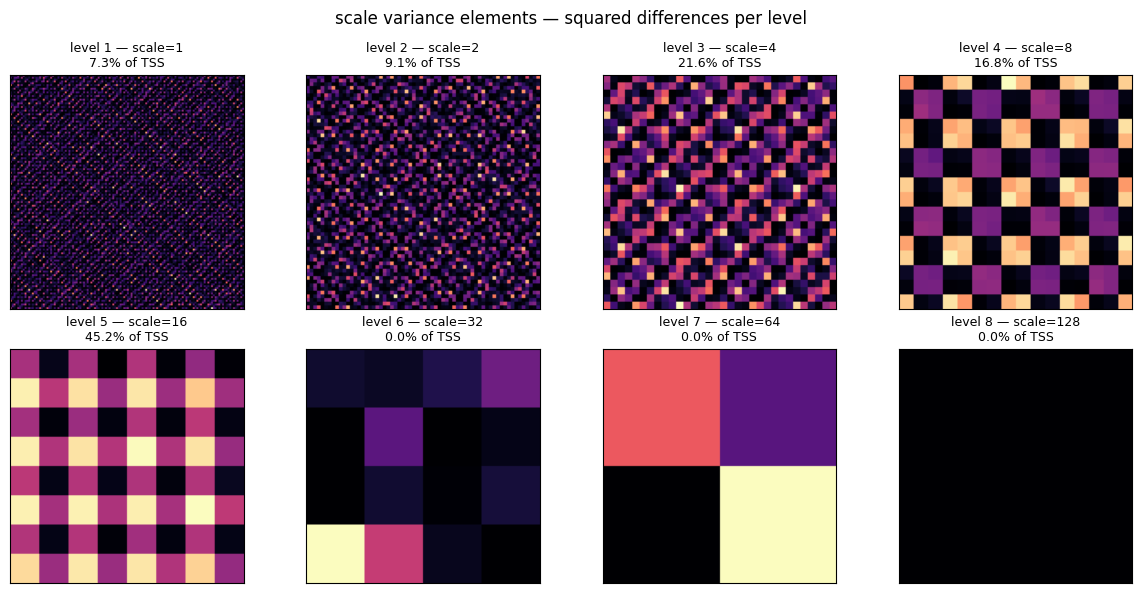

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    result_sve = scale_variance_raster(raster, agg_fun='mean', return_sve=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for lvl, ax in enumerate(axes.ravel(), start=1):
    band = result_sve.sve[lvl-1]
    scale = result_sve.components.loc[lvl-1, 'scale']
    share = result_sve.components.loc[lvl-1, 'ss_share']
    im = ax.imshow(band, cmap='magma', origin='lower')
    ax.set_title(f'level {lvl} — scale={scale:.0f}\n{share*100:.1f}% of TSS', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('scale variance elements — squared differences per level')
fig.tight_layout()
plt.show()